In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.optimize import minimize
from scipy.special import erf

plt.style.use('stefan.mplstyle')
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'text.latex.preamble': r'\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Sample Selection

In [3]:
df = pd.read_csv('../data/tyler/WDMS_total_ages_correct_models_cut_down.csv')

df['age_frac_err'] = np.maximum(
    df['tot_age_error_upper'].fillna(np.inf),
    df['tot_age_error_lower'].fillna(np.inf)
) / df['tot_age'].replace(0, np.nan)

mask = (
    (df['age_frac_err'] < 0.20) &
    (df['phot_bp_rp_excess_factor'] < 1.2) &
    (df['Mass'] > 0.63) &
    (df['spectype'] != '0.0') &
    df['tot_age'].notna() & (df['tot_age'] > 0) &
    df['wtd_par'].notna() & (df['wtd_par'] > 0)
)
data = df[mask].copy().reset_index(drop=True)
print(f'N = {len(data)}')

N = 485


## Transverse Velocity in Galactic Coordinates

In [4]:
# Rotate ICRS proper motions to Galactic frame
coords = SkyCoord(
    ra=data['ra'].values * u.deg,
    dec=data['dec'].values * u.deg,
    pm_ra_cosdec=data['pmra'].values * u.mas / u.yr,
    pm_dec=data['pmdec'].values * u.mas / u.yr,
    frame='icrs'
)
gal = coords.galactic
pm_l_cosb = gal.pm_l_cosb.to(u.mas / u.yr).value
pm_b      = gal.pm_b.to(u.mas / u.yr).value

# km/s: v = 4.74047 * mu[mas/yr] * d[kpc]
d_kpc = 1.0 / data['wtd_par'].values  # wtd_par in mas
v_l_helio = 4.74047 * pm_l_cosb * d_kpc
v_b_helio = 4.74047 * pm_b      * d_kpc

# Solar motion correction (Schönrich et al. 2010 via Cheng 2019)
U_sun, V_sun, W_sun = 11.0, 12.0, 7.0  # km/s
l_rad = np.radians(data['l'].values)
b_rad = np.radians(data['b'].values)

v_l_sun = -U_sun * np.sin(l_rad) + V_sun * np.cos(l_rad)
v_b_sun = (-U_sun * np.cos(l_rad) * np.sin(b_rad)
           -V_sun * np.sin(l_rad) * np.sin(b_rad)
           +W_sun * np.cos(b_rad))

data['v_l'] = v_l_helio - v_l_sun
data['v_b'] = v_b_helio - v_b_sun

# Absolute values for the histograms
data['abs_v_l'] = np.abs(data['v_l'])
data['abs_v_b'] = np.abs(data['v_b'])

print(f'sigma_l = {data["v_l"].std():.1f} km/s')
print(f'sigma_b = {data["v_b"].std():.1f} km/s')

sigma_l = 40.3 km/s
sigma_b = 26.8 km/s


## Cheng 2019 AVR

In [5]:
# Best-fit values from Cheng et al. (2019) MCMC posteriors
AVR = dict(
    sigma_U0=5.78, dSigma_U04=26.09, beta_U=0.35, sigma_U_thick=66.07,
    k_thin=0.68, k_thick=0.64,
    sigma_W0=3.81, dSigma_W04=11.97, beta_W=0.60, sigma_W_thick=34.07,
)


def _avr_thin_thick(tau, s0, ds, beta, s_thick):
    tau = np.asarray(tau, float)
    s_7 = s0 + ds * (7.0 / 4.0) ** beta
    frac = np.clip((tau - 7.0) / 3.0, 0.0, 1.0)
    return np.where(tau < 7.0, s0 + ds * (tau / 4.0) ** beta,
           np.where(tau > 10.0, s_thick, s_7 + frac * (s_thick - s_7)))


def avr_sigmas(tau):
    """sigma_U, sigma_V, sigma_W at age tau [Gyr] (arrays OK)."""
    tau = np.asarray(tau, float)
    sU = _avr_thin_thick(tau, AVR['sigma_U0'],  AVR['dSigma_U04'],  AVR['beta_U'],  AVR['sigma_U_thick'])
    sW = _avr_thin_thick(tau, AVR['sigma_W0'],  AVR['dSigma_W04'],  AVR['beta_W'],  AVR['sigma_W_thick'])
    frac = np.clip((tau - 7.0) / 3.0, 0.0, 1.0)
    k = np.where(tau < 7.0, AVR['k_thin'],
        np.where(tau > 10.0, AVR['k_thick'],
                 AVR['k_thin'] + frac * (AVR['k_thick'] - AVR['k_thin'])))
    return sU, k * sU, sW


def projected_sigma_lb(tau, l_deg, b_deg):
    """
    Project (sigma_U, sigma_V, sigma_W) onto the Galactic tangential plane.
    v_l = -U sin(l) + V cos(l)
    v_b = -U cos(l)sin(b) - V sin(l)sin(b) + W cos(b)
    Returns sigma_l, sigma_b [km/s].
    """
    sU, sV, sW = avr_sigmas(tau)
    l, b = np.radians(l_deg), np.radians(b_deg)
    sl = np.sqrt(sU**2 * np.sin(l)**2 + sV**2 * np.cos(l)**2)
    sb = np.sqrt(sU**2 * np.cos(l)**2 * np.sin(b)**2
               + sV**2 * np.sin(l)**2 * np.sin(b)**2
               + sW**2 * np.cos(b)**2)
    return sl, sb

## Histogram Setup and Expected Distribution

For each star at age $\tau_i$ and position $(l_i, b_i)$ the AVR gives $\sigma_{l,i}$ and $\sigma_{b,i}$.
The expected count in bin $[v_1, v_2]$ is:
$$N_\mathrm{exp}(v_1, v_2) = \sum_i \left[\mathrm{erf}\!\left(\frac{v_2}{\sigma_{l,i}\sqrt{2}}\right) - \mathrm{erf}\!\left(\frac{v_1}{\sigma_{l,i}\sqrt{2}}\right)\right]$$
(analogously for $\sigma_{b,i}$), using the half-normal CDF since we plot $|v|$.

In [6]:
# Histogram bins: 0-100 km/s, 10 bins of 10 km/s
bins = np.arange(0, 101, 10)
bw   = 10.0
bc   = 0.5 * (bins[:-1] + bins[1:])  # centers: 5, 15, ..., 95

counts_l, _ = np.histogram(data['abs_v_l'], bins=bins)
counts_b, _ = np.histogram(data['abs_v_b'], bins=bins)


def gehrels_errors(n):
    """Asymmetric Poisson 1-sigma errors (Gehrels 1986)."""
    n = np.asarray(n, float)
    err_hi = (n + 1.0) * (1.0 - 1.0/(9.0*(n+1.0)) + 1.0/(3.0*np.sqrt(n+1.0)))**3 - n
    err_lo = n - n * (1.0 - 1.0/(9.0*n) - 1.0/(3.0*np.sqrt(n)))**3
    err_lo = np.where(n == 0, 0.0, err_lo)
    return err_lo, err_hi


def expected_counts(ages, l_deg, b_deg, bins, component='l'):
    """
    Expected histogram counts under single-star evolution.
    Sum of half-normal CDFs over all stars at their measured ages.
    """
    sl, sb = projected_sigma_lb(ages, l_deg, b_deg)
    sigmas = sl if component == 'l' else sb

    counts = np.zeros(len(bins) - 1)
    for i in range(len(bins) - 1):
        v1, v2 = bins[i], bins[i+1]
        # Half-normal CDF: P(|v| < x) = erf(x / (sigma * sqrt(2)))
        counts[i] = np.sum(
            erf(v2 / (sigmas * np.sqrt(2))) - erf(v1 / (sigmas * np.sqrt(2)))
        )
    return counts


exp_l = expected_counts(data['tot_age'].values, data['l'].values, data['b'].values, bins, 'l')
exp_b = expected_counts(data['tot_age'].values, data['l'].values, data['b'].values, bins, 'b')

el_lo, el_hi = gehrels_errors(counts_l)
eb_lo, eb_hi = gehrels_errors(counts_b)

## Figure 1: Velocity Distribution vs Expected

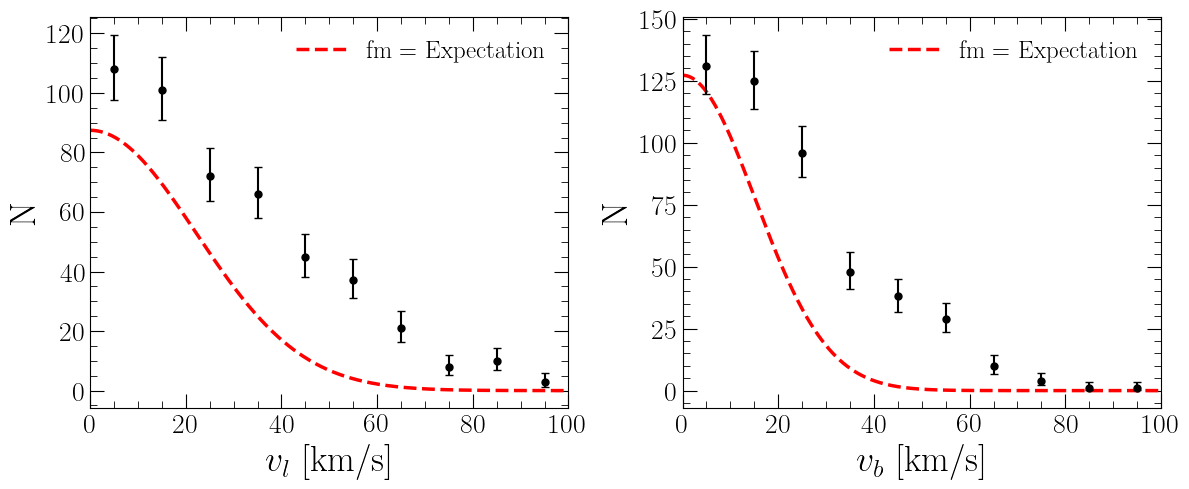

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, el, eh, exp, xlabel in zip(
    axes,
    [counts_l, counts_b],
    [el_lo, eb_lo],
    [el_hi, eb_hi],
    [exp_l, exp_b],
    [r'$v_l$ [km/s]', r'$v_b$ [km/s]'],
):
    ax.errorbar(bc, counts, yerr=[el, eh], fmt='o', color='k', ms=5, capsize=3, zorder=5)
    # Smooth expected curve
    v_smooth = np.linspace(0, 100, 400)
    # Use average sigma over the sample for a smooth curve
    sl, sb = projected_sigma_lb(data['tot_age'].values, data['l'].values, data['b'].values)
    sigma_avg = np.mean(sl) if 'v_l' in xlabel else np.mean(sb)
    exp_smooth = len(data) * (2.0 / (sigma_avg * np.sqrt(2*np.pi))) * np.exp(-v_smooth**2 / (2*sigma_avg**2)) * bw
    ax.plot(v_smooth, exp_smooth, color='red', ls='--', lw=2.5, label='fm = Expectation')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('N')
    ax.set_xlim(0, 100)
    ax.legend(framealpha=0)

fig.tight_layout()
fig.savefig('../notebooks/velocity-dispersion/vel_dist_new.pdf')
plt.show()

## Figure 2: Velocity Fit with Age Weights

Fit the observed $|v_l|$ and $|v_b|$ distributions simultaneously with:
$$N_\mathrm{expected}(v) = A \sum_{i=1}^{40} w_i \exp\!\left(-\frac{v^2}{2\sigma_i^2}\right)$$
where ages $\tau_i = 0.25, 0.50, \ldots, 10\,\text{Gyr}$ and $\sigma_i$ is the sample-averaged
projected dispersion at age $\tau_i$.  Fit is run 100 times from random starts (non-negative weights).

In [8]:
age_grid = np.arange(0.25, 10.25, 0.25)  # 40 values
n_ages   = len(age_grid)
N        = len(data)
l_arr    = data['l'].values
b_arr    = data['b'].values

# Sample-averaged projected sigma for each age bin
sigma_l_grid = np.zeros(n_ages)
sigma_b_grid = np.zeros(n_ages)
for k, tau in enumerate(age_grid):
    sl, sb = projected_sigma_lb(np.full(N, tau), l_arr, b_arr)
    sigma_l_grid[k] = sl.mean()
    sigma_b_grid[k] = sb.mean()


def half_normal_counts(sigma, bins):
    """Expected counts per bin for |v| ~ HalfNormal(sigma), normalized to 1."""
    return np.array([
        erf(bins[i+1] / (sigma * np.sqrt(2))) - erf(bins[i] / (sigma * np.sqrt(2)))
        for i in range(len(bins)-1)
    ])


# Design matrices: G_l[k, i] = expected fraction in bin k for age i (v_l component)
G_l = np.column_stack([half_normal_counts(s, bins) for s in sigma_l_grid])  # (10, 40)
G_b = np.column_stack([half_normal_counts(s, bins) for s in sigma_b_grid])

# Stack for joint fit
G_joint = np.vstack([G_l, G_b])                        # (20, 40)
y_joint = np.concatenate([counts_l, counts_b]).astype(float)
err_j   = np.sqrt(np.maximum(y_joint, 1.0))

Gw = G_joint / err_j[:, None]
yw = y_joint / err_j

# Objective: chi-squared with non-negative weights
def chi2(w):
    return np.sum((yw - Gw @ w)**2)

def chi2_grad(w):
    r = yw - Gw @ w
    return -2.0 * Gw.T @ r

bounds = [(0, None)] * n_ages
rng    = np.random.default_rng(42)

best_w   = None
best_chi = np.inf

for _ in range(100):
    w0 = rng.exponential(scale=N / n_ages, size=n_ages)
    res = minimize(chi2, w0, jac=chi2_grad, method='L-BFGS-B', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-12})
    if res.fun < best_chi:
        best_chi = res.fun
        best_w   = res.x.copy()

print(f'Best chi2/dof = {best_chi / (len(y_joint) - np.count_nonzero(best_w)):.2f}')
print(f'Non-zero age components: {np.count_nonzero(best_w > 1e-3)}')

Best chi2/dof = 0.97
Non-zero age components: 5


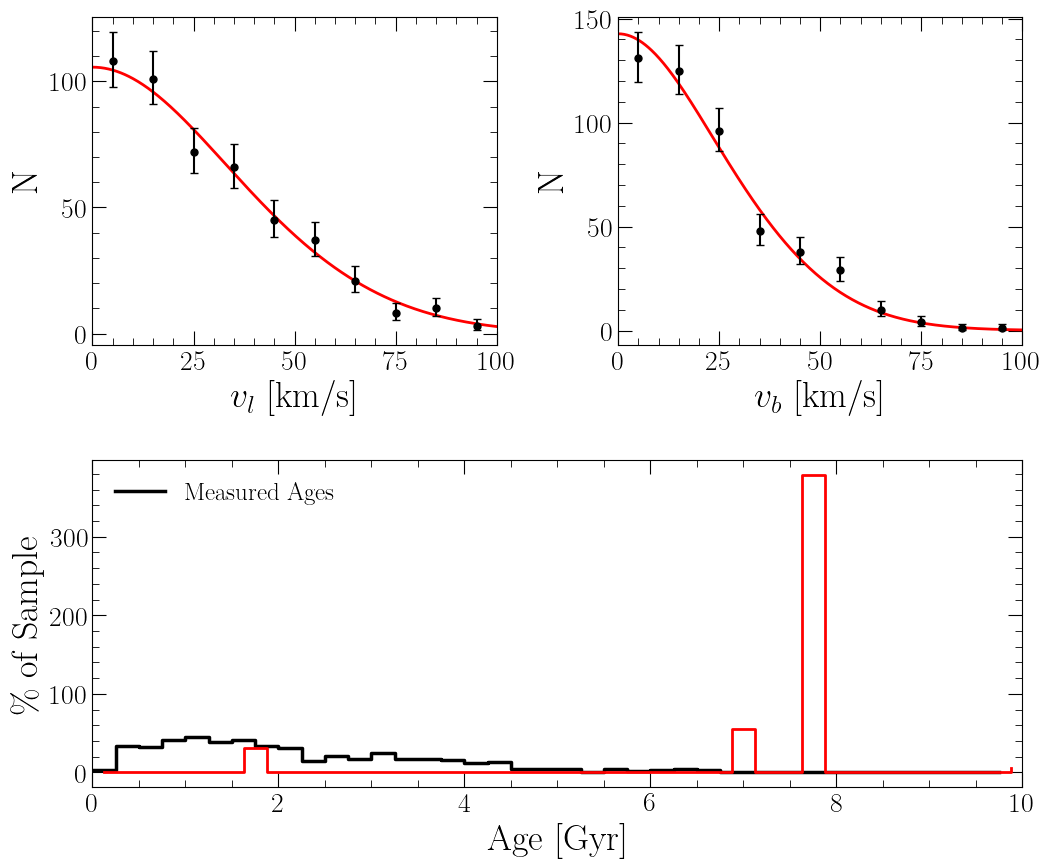

In [9]:
# Reconstruct best-fit velocity distributions
fit_l_counts = G_l @ best_w  # expected fraction * N_total
fit_b_counts = G_b @ best_w

# Smooth fit curves for plotting
v_smooth = np.linspace(0, 100, 400)

def fit_smooth(v, sigmas, weights):
    result = np.zeros_like(v)
    for s, w in zip(sigmas, weights):
        result += w * (2.0 / (s * np.sqrt(2*np.pi))) * np.exp(-v**2 / (2*s**2))
    return result * bw

smooth_l = fit_smooth(v_smooth, sigma_l_grid, best_w)
smooth_b = fit_smooth(v_smooth, sigma_b_grid, best_w)

# --- Plot ---
fig = plt.figure(figsize=(12, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)
ax_l  = fig.add_subplot(gs[0, 0])
ax_b  = fig.add_subplot(gs[0, 1])
ax_age = fig.add_subplot(gs[1, :])

for ax, counts, el, eh, smooth, xlabel in zip(
    [ax_l, ax_b],
    [counts_l, counts_b],
    [el_lo, eb_lo],
    [el_hi, eb_hi],
    [smooth_l, smooth_b],
    [r'$v_l$ [km/s]', r'$v_b$ [km/s]'],
):
    ax.errorbar(bc, counts, yerr=[el, eh], fmt='o', color='k', ms=5, capsize=3, zorder=5)
    ax.plot(v_smooth, smooth, color='red', lw=2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('N')
    ax.set_xlim(0, 100)

# Age distribution panel
age_bins = np.arange(0, 10.25, 0.25)
obs_hist, _ = np.histogram(data['tot_age'], bins=age_bins)
obs_pct = 100.0 * obs_hist / N

fit_pct = 100.0 * best_w / best_w.sum()

ax_age.step(age_bins[:-1], obs_hist, where='post', color='k', lw=2.5, label='Measured Ages')
ax_age.step(age_grid - 0.125, best_w, where='post', color='red', lw=2)
ax_age.set_xlabel('Age [Gyr]')
ax_age.set_ylabel(r'\% of Sample')
ax_age.set_xlim(0, 10)
ax_age.legend(framealpha=0)

fig.savefig('../notebooks/velocity-dispersion/vel_fit_new.pdf')
plt.show()

## Figure 3: Merger Fraction Exploration

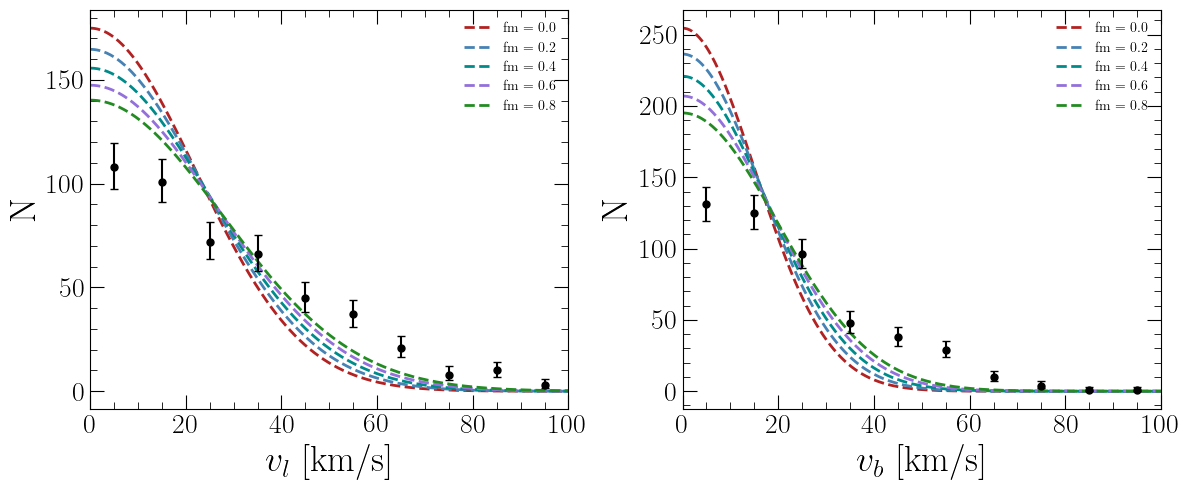

In [10]:
merger_fractions = [0.0, 0.2, 0.4, 0.6, 0.8]
colors_m = ['firebrick', 'steelblue', 'darkcyan', 'mediumpurple', 'forestgreen']
n_trials = 100
rng_m    = np.random.default_rng(7)

ages_obs = data['tot_age'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, el, eh, xlabel in zip(
    axes,
    [counts_l, counts_b],
    [el_lo, eb_lo],
    [el_hi, eb_hi],
    [r'$v_l$ [km/s]', r'$v_b$ [km/s]'],
):
    ax.errorbar(bc, counts, yerr=[el, eh], fmt='o', color='k', ms=5, capsize=3, zorder=5)

for frac, col in zip(merger_fractions, colors_m):
    v_smooth_m = np.linspace(0, 100, 400)
    avg_l = np.zeros_like(v_smooth_m)
    avg_b = np.zeros_like(v_smooth_m)

    for _ in range(n_trials):
        ages_mod = ages_obs.copy()
        n_merge  = int(frac * N)
        if n_merge > 0:
            idx = rng_m.choice(N, size=n_merge, replace=False)
            ages_mod[idx] += rng_m.uniform(0, 5, size=n_merge)

        sl, sb = projected_sigma_lb(ages_mod, l_arr, b_arr)
        sigma_l_avg = sl.mean()
        sigma_b_avg = sb.mean()

        avg_l += (2.0 / (sigma_l_avg * np.sqrt(2*np.pi))) * np.exp(-v_smooth_m**2 / (2*sigma_l_avg**2)) * bw * N
        avg_b += (2.0 / (sigma_b_avg * np.sqrt(2*np.pi))) * np.exp(-v_smooth_m**2 / (2*sigma_b_avg**2)) * bw * N

    avg_l /= n_trials
    avg_b /= n_trials

    lbl = f'fm = {frac:.1f}'
    axes[0].plot(v_smooth_m, avg_l, color=col, ls='--', lw=2, label=lbl)
    axes[1].plot(v_smooth_m, avg_b, color=col, ls='--', lw=2, label=lbl)

for ax, xlabel in zip(axes, [r'$v_l$ [km/s]', r'$v_b$ [km/s]']):
    ax.set_xlabel(xlabel)
    ax.set_ylabel('N')
    ax.set_xlim(0, 100)
    ax.legend(framealpha=0, fontsize=10)

fig.tight_layout()
fig.savefig('../notebooks/velocity-dispersion/vel_dist_mergers_new.pdf')
plt.show()